## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import shap
import ast

from collections import defaultdict, deque
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix

c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Engineering
Create Relational features from absolute feature to prevent redundancy between features and make easier model to analize data pattern.

In [2]:
df_matches = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\matches.csv")
df_matches.head(10)

,match_keys,date,tier_name,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,winner,score,match_id
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,aurora gaming ph,0-2,1
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,onic philippines,2-0,2
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,team liquid ph,0-2,3
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,tnc pro team,2-0,4
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,aurora gaming ph,2-1,5
5,2025-03-02 16:00:00+07:00_MPL Philippines Seas...,2025-03-02 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,omega esports,team falcons ph,0,2,team falcons ph,0-2,6
6,2025-03-02 18:30:00+07:00_MPL Philippines Seas...,2025-03-02 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team liquid ph,twisted minds ph,2,0,team liquid ph,2-0,7
7,2025-03-07 15:15:00+07:00_MPL Indonesia Season...,2025-03-07 15:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,natus vincere,rrq hoshi,0,2,rrq hoshi,0-2,8
8,2025-03-07 16:00:00+07:00_MPL Philippines Seas...,2025-03-07 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,onic philippines,2,1,team falcons ph,2-1,9
9,2025-03-07 18:15:00+07:00_MPL Indonesia Season...,2025-03-07 18:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,evos,team liquid id,2,1,evos,2-1,10


In [45]:
df_games = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\games.csv")
df_games.head(10)

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,away_gold_5mnt,home_gold_10mnt,away_gold_10mnt,home_gold_15mnt,away_gold_15mnt,home_gold_20mnt,away_gold_20mnt,game_id,home_score,away_score
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17:52,...,-1800.0,4000.0,-4000.0,4800.0,-4800.0,NaN,NaN,1,1,0
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21:55,...,67.0,-2700.0,2700.0,-6400.0,6400.0,-6000.0,6000.0,2,1,0
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:52,...,1500.0,-3500.0,3500.0,-8000.0,8000.0,NaN,NaN,3,0,1
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13:52,...,1400.0,-7800.0,7800.0,NaN,NaN,NaN,NaN,4,0,1
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19:48,...,-1600.0,6900.0,-6900.0,5400.0,-5400.0,NaN,NaN,5,1,0
5,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:41,...,-540.0,-1000.0,1000.0,NaN,NaN,NaN,NaN,6,0,1
6,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,3,default,16:02,...,-153.0,3500.0,-3500.0,2600.0,-2600.0,NaN,NaN,7,1,0
7,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:34,...,503.0,401.0,-401.0,-3500.0,3500.0,NaN,NaN,8,0,1
8,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:31,...,1300.0,-8700.0,8700.0,NaN,NaN,NaN,NaN,9,0,1
9,2025-03-01 16:00:00+07:00,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,13:12,...,-2200.0,8200.0,-8200.0,NaN,NaN,NaN,NaN,10,1,0


Change a list contained feature into wide format

In [46]:
def item_explode(columns):
    team_picks = []
    for i in columns:
        stat = ast.literal_eval(i)
        team_picks.append(stat)
    return team_picks

for team in ["home", "away"]:
    for step in ["picks", "bans"]:
        df_games[team + "_" + step] = item_explode(df_games[team + "_" + step])
        df_games[[
            team + "_" + step + "_" + "1", team + "_" + step + "_" + "2", team + "_" + step + "_" + "3", team + "_" + step + "_" + "4", team + "_" + step + "_" + "5"
        ]] = pd.DataFrame(df_games[team + "_" + step].tolist(), index=df_games.index)

# df_games["home_picks"] = item_explode(df_games["home_picks"])
# df_games[["home_picks_1", "home_picks_2", "home_picks_3", "home_picks_4", "home_picks_5"]] = pd.DataFrame(df_games["home_picks"].tolist(), index=df_games.index)
# df_games["away_picks"] = item_explode(df_games["away_picks"])
# df_games[["away_picks_1", "away_picks_2", "away_picks_3", "away_picks_4", "away_picks_5"]] = pd.DataFrame(df_games["away_picks"].tolist(), index=df_games.index)
# df_games["home_bans"] = item_explode(df_games["home_bans"])
# df_games[["home_bans_1", "home_bans_2", "home_bans_3", "home_bans_4", "home_bans_5"]] = pd.DataFrame(df_games["home_bans"].tolist(), index=df_games.index)
# df_games["away_bans"] = item_explode(df_games["away_bans"])
# df_games[["away_bans_1", "away_bans_2", "away_bans_3", "away_bans_4", "away_bans_5"]] = pd.DataFrame(df_games["away_bans"].tolist(), index=df_games.index)

Display row with NaN values

In [47]:
test = df_games.copy()
test = test.drop(columns=test.columns[:-20])
test[test.isna().any(axis=1)]

,home_picks_1,home_picks_2,home_picks_3,home_picks_4,home_picks_5,home_bans_1,home_bans_2,home_bans_3,home_bans_4,home_bans_5,away_picks_1,away_picks_2,away_picks_3,away_picks_4,away_picks_5,away_bans_1,away_bans_2,away_bans_3,away_bans_4,away_bans_5
117,Badang,Hanzo,Yve,Beatrix,Tigreal,Zhuxin,Mathilda,Luo Yi,Hylos,None,Hilda,Ling,Cecilion,Granger,Khaleed,Gatotkaca,Fanny,Harith,Cici,Joy
140,Phoveus,Suyou,Pharsa,Brody,Jawhead,Zhuxin,Luo Yi,Chip,None,None,Hilda,Fanny,Aurora,Granger,Chou,Mathilda,Harith,Moskov,None,None
600,Hylos,Suyou,Aurora,Irithel,Gatotkaca,Luo Yi,Hanzo,Kalea,Lukas,None,Julian,Fanny,Zhuxin,Clint,Grock,Harith,Mathilda,Chip,Phoveus,None
943,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
973,X.Borg,Fanny,Kimmy,Granger,Chip,Phoveus,Kalea,Badang,Vexana,None,Gloo,Hayabusa,Zhuxin,Irithel,Mathilda,Cecilion,Luo Yi,Lukas,Harith,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,Esmeralda,Lancelot,Valentina,Harith,Gatotkaca,Chip,Fanny,Wanwan,None,None,Uranus,Yi Sun-shin,Angela,Bane,Khaleed,Arlott,Cici,Zhuxin,None,None
2185,Ruby,Lancelot,Pharsa,Bruno,Kaja,Kimmy,Yve,Natan,Akai,None,Cici,Lukas,Zetian,Irithel,Khaleed,Angela,Zhuxin,Grock,Lapu-Lapu,X.Borg
2226,Uranus,Baxia,Kimmy,Obsidia,Mathilda,Joy,Esmeralda,Chip,None,None,Cici,Lancelot,Bane,Brody,Gatotkaca,Yve,Lunox,Zhuxin,Kalea,None
2572,Esmeralda,Yi Sun-shin,Pharsa,Harith,Hilda,Grock,Uranus,Arlott,Lapu-Lapu,None,Gloo,Lancelot,Kimmy,Brody,Hylos,Baxia,Zhuxin,Kalea,Gatotkaca,Kaja


In [48]:
# Calculate Draft intelligence (on progress)
hero_stat = defaultdict(lambda:{
    "win": 0,
    "total": 0
})

# Smooting constant
gamma = 0.05

def get_hero_winrate(team, hero):
    if pd.isna(hero):
        return np.nan
    
    key = (team, hero)
    stats = hero_stat[key]
    
    return (stats["win"] + 1) / (stats["total"] + 2)

history = []

for i, row in df_games.iterrows():
    keys = row["match_keys"]
    t1, t2 = row["home_team"], row["away_team"]
    st1, st2 = row["home_status"], row["away_status"]
    hp1, ap1 = row["home_picks_1"], row["away_picks_1"]
    hp2, ap2 = row["home_picks_2"], row["away_picks_2"]
    hp3, ap3 = row["home_picks_3"], row["away_picks_3"]
    hp4, ap4 = row["home_picks_4"], row["away_picks_4"]
    hp5, ap5 = row["home_picks_5"], row["away_picks_5"]

    s1 = 1 if st1 == "win" else 0
    s2 = 1 if st2 == "win" else 0

    for team in [t1, t2]:
        if team == t1:
            home_draft_wr = []
            for hero in [hp1, hp2, hp3, hp4, hp5]:
                hero_wr = get_hero_winrate(team, hero)
                home_draft_wr.append(hero_wr)
                
                hero_stat[(team, hero)]["win"] += s1 if not pd.isna(hero) else np.nan
                hero_stat[(team, hero)]["total"] += 1 if not pd.isna(hero) else np.nan
            home_draft_wr = np.mean(home_draft_wr)
        if team == t2:
            away_draft_wr = []
            for hero in [ap1, ap2, ap3, ap4, ap5]:
                hero_wr = get_hero_winrate(team, hero)
                away_draft_wr.append(hero_wr)
                
                hero_stat[(team, hero)]["win"] += s2 if not pd.isna(hero) else np.nan
                hero_stat[(team, hero)]["total"] += 1 if not pd.isna(hero) else np.nan
            away_draft_wr = np.mean(away_draft_wr)

    draft_wr_diff = home_draft_wr - away_draft_wr
    history.append({
        "home_draft_wr": home_draft_wr,
        "away_draft_wr": away_draft_wr,
        "draft_wr_diff": draft_wr_diff
    })

df = pd.DataFrame(history)
df

,home_draft_wr,away_draft_wr,draft_wr_diff
0,0.500000,0.500000,0.000000
1,0.533333,0.500000,0.033333
2,0.500000,0.500000,0.000000
3,0.466667,0.533333,-0.066667
4,0.550000,0.533333,0.016667
...,...,...,...
3370,0.735000,0.580592,0.154408
3371,0.707703,0.669641,0.038062
3372,0.709837,0.685641,0.024196
3373,0.718615,0.723578,-0.004964


In [49]:
df_games = df_games.drop(columns=df_games.columns[-20:])
df_games["home_draft_wr"] = df["home_draft_wr"].round(2)
df_games["away_draft_wr"] = df["away_draft_wr"].round(2)
df_games["draft_wr_diff"] = df["draft_wr_diff"].round(2)
df_games

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,home_gold_15mnt,away_gold_15mnt,home_gold_20mnt,away_gold_20mnt,game_id,home_score,away_score,home_draft_wr,away_draft_wr,draft_wr_diff
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17:52,...,4800.0,-4800.0,NaN,NaN,1,1,0,0.50,0.50,0.00
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21:55,...,-6400.0,6400.0,-6000.0,6000.0,2,1,0,0.53,0.50,0.03
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:52,...,-8000.0,8000.0,NaN,NaN,3,0,1,0.50,0.50,0.00
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13:52,...,NaN,NaN,NaN,NaN,4,0,1,0.47,0.53,-0.07
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19:48,...,5400.0,-5400.0,NaN,NaN,5,1,0,0.55,0.53,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,2025-12-23 21:00:00+07:00,2025-12-23 21:00:00+07:00_Games of the Future ...,2025-12-23 21:00:00+07:00_Games of the Future ...,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Grand Final,1,Broken Walls,15:47,...,-8400.0,8400.0,NaN,NaN,3371,0,1,0.74,0.58,0.15
3371,2025-12-23 21:00:00+07:00,2025-12-23 21:00:00+07:00_Games of the Future ...,2025-12-23 21:00:00+07:00_Games of the Future ...,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Grand Final,2,Dangerous Grass,17:38,...,-9700.0,9700.0,NaN,NaN,3372,0,1,0.71,0.67,0.04
3372,2025-12-23 21:00:00+07:00,2025-12-23 21:00:00+07:00_Games of the Future ...,2025-12-23 21:00:00+07:00_Games of the Future ...,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Grand Final,3,Expanding Rivers,14:06,...,NaN,NaN,NaN,NaN,3373,0,1,0.71,0.69,0.02
3373,2025-12-23 18:00:00+07:00,2025-12-23 18:00:00+07:00_Games of the Future ...,2025-12-23 18:00:00+07:00_Games of the Future ...,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Third Place,1,Flying Cloud,13:58,...,NaN,NaN,NaN,NaN,3374,0,1,0.72,0.72,-0.00


In [50]:
def kda_score(kill, assist, death):
    if np.nan in death or 0.0 in death:
        kda = kill + assist
        return kda
    
    kda = (kill + assist) / death
    return kda

def scale_score(feature1, feature2):
    if np.nan in feature1 or np.nan in feature2:
        return np.nan
    
    return feature1 / feature2

def diff_score(feature1, feature2):
    return feature1 - feature2
    
def time_converts(time_str):
    if pd.isna(time_str):
        return np.nan
    m, s = map(int, time_str.split(":"))
    duration = m + (s / 60)
    return duration

Create relational features such gold_eff, kda_diff, objective_diff, early_gold_diff, mid_gold_diff, late_gold_diff and comeback flag.

In [51]:
df_games["duration"] = [time_converts(i) for i in df_games["duration"]]
df_games["home_score"] = np.where(df_games["home_status"] == "win", 1, 0)
df_games["away_score"] = np.where(df_games["away_status"] == "win", 1, 0)
df_games["gold_total_diff"] = diff_score(df_games["home_gold_total"], df_games["away_gold_total"])
df_games["gold_eff"] = scale_score(df_games["gold_total_diff"], df_games["duration"])
df_games["objective_diff"] = diff_score(
    df_games["home_turtles"] + df_games["home_lords"] + df_games["home_towers"],
    df_games["away_turtles"] + df_games["away_lords"] + df_games["away_towers"]
)
df_games["kda_diff"] = diff_score(
    kda_score(df_games["home_kills"], df_games["home_assists"], df_games["home_deaths"]),
    kda_score(df_games["away_kills"], df_games["away_assists"], df_games["away_deaths"])
)
df_games["early_gold_diff"] = df_games["home_gold_5mnt"]
df_games["is_mid_game"] = (df_games["duration"] >= 10.0).astype(int)
df_games["mid_gold_diff"] = diff_score(df_games["home_gold_10mnt"], df_games["home_gold_5mnt"])
df_games["is_late_game"] = (df_games["duration"] >= 15.0).astype(int)
df_games["late_gold_diff"] = diff_score(df_games["home_gold_15mnt"], df_games["home_gold_10mnt"])
df_games["is_very_late_game"] = (df_games["duration"] >= 20.0).astype(int)
df_games["very_late_gold_diff"] = diff_score(df_games["home_gold_20mnt"], df_games["home_gold_15mnt"])
# df_games["home_is_comeback"] = (((df_games["early_gold_diff"] < 0) | (df_games["mid_gold_diff"] < 0) | (df_games["early_gold_diff"] < 0)) & (df_games["home_score"] == 1)).astype(int)
# df_games["home_behind_any_phase"] = ((df_games["early_gold_diff"] < 0) | (df_games["mid_gold_diff"] < 0) | (df_games["late_gold_diff"] < 0)).astype(int)
# df_games["away_is_comeback"] = (((-(df_games["early_gold_diff"]) < 0) | (-(df_games["mid_gold_diff"]) < 0) | (-(df_games["early_gold_diff"]) < 0)) & (df_games["away_score"] == 1)).astype(int)
# df_games["away_behind_any_phase"] = ((-(df_games["early_gold_diff"]) < 0) | (-(df_games["mid_gold_diff"]) < 0) | (-(df_games["late_gold_diff"]) < 0)).astype(int)
df_games = df_games.drop(columns=df_games.columns[20:44])
df_games = df_games.drop(columns=["home_status", "away_status"])

In [52]:
df_games.head(10)

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,gold_eff,objective_diff,kda_diff,early_gold_diff,is_mid_game,mid_gold_diff,is_late_game,late_gold_diff,is_very_late_game,very_late_gold_diff
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17.866667,...,380.597015,7.0,26.0,1800.0,1,2200.0,1,800.0,0,NaN
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21.916667,...,136.882129,-7.0,-19.0,-67.0,1,-2633.0,1,-3700.0,1,400.0
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18.866667,...,-482.332155,-6.0,-32.0,-1500.0,1,-2000.0,1,-4500.0,0,NaN
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13.866667,...,-937.500000,-14.0,-23.0,-1400.0,1,-6400.0,0,NaN,0,NaN
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19.800000,...,262.626263,14.0,8.0,1600.0,1,5300.0,1,-1500.0,0,NaN
5,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12.683333,...,-433.639947,-7.0,-29.0,540.0,1,-1540.0,0,NaN,0,NaN
6,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,3,default,16.033333,...,187.110187,3.0,41.0,153.0,1,3347.0,1,-900.0,0,NaN
7,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18.566667,...,-355.475763,-7.0,-28.0,-503.0,1,904.0,1,-3901.0,0,NaN
8,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12.516667,...,-990.679095,-12.0,-26.0,-1300.0,1,-7400.0,0,NaN,0,NaN
9,2025-03-01 16:00:00+07:00,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,13.200000,...,803.030303,9.0,43.0,2200.0,1,6000.0,0,NaN,0,NaN


Aggregation games based dataset into match based dataset

In [53]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3375 entries, 0 to 3374
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 3375 non-null   object 
 1   match_keys           3375 non-null   object 
 2   game_keys            3375 non-null   object 
 3   tier_name            3375 non-null   object 
 4   tournament_name      3375 non-null   object 
 5   stage_name           3375 non-null   object 
 6   bracket_name         3375 non-null   object 
 7   game_num             3375 non-null   int64  
 8   map_name             3307 non-null   object 
 9   duration             3355 non-null   float64
 10  home_team            3375 non-null   object 
 11  away_team            3375 non-null   object 
 12  home_alias           3375 non-null   object 
 13  away_alias           3375 non-null   object 
 14  home_picks           3375 non-null   object 
 15  away_picks           3375 non-null   o

In [54]:
match_stat_avg = df_games.groupby(["match_keys"]).agg(
    duration=("duration", "mean"),
    home_team=("home_team", "first"),
    away_team=("away_team", "first"),
    home_draft_wr=("home_draft_wr", "mean"),
    away_draft_wr=("away_draft_wr", "mean"),
    draft_wr_diff=("draft_wr_diff", "mean"),
    gold_total_diff=("gold_total_diff", "mean"),
    gold_eff=("gold_eff", "mean"),
    objective_diff=("objective_diff", "mean"),
    kda_diff=("kda_diff", "mean"),
    early_gold_diff=("early_gold_diff", "mean"),
    is_mid_game=("is_mid_game", "mean"),
    mid_gold_diff=("mid_gold_diff", "mean"),
    is_late_game=("is_late_game", "mean"),
    late_gold_diff=("late_gold_diff", "mean"),
    is_very_late_game=("is_very_late_game", "mean"),
    very_late_gold_diff=("very_late_gold_diff", "mean")
    # home_is_comeback=("home_is_comeback", "sum"),
    # home_behind_any_phase=("home_behind_any_phase", "sum"),
    # away_is_comeback=("away_is_comeback", "sum"),
    # away_behind_any_phase=("away_behind_any_phase", "sum")
).reset_index()
# match_stat_avg["home_comeback_rate"] = (match_stat_avg["home_is_comeback"] / match_stat_avg["home_behind_any_phase"]).fillna(0).round(2)
# match_stat_avg["away_comeback_rate"] = (match_stat_avg["away_is_comeback"] / match_stat_avg["away_behind_any_phase"]).fillna(0).round(2)
# match_stat_avg["comeback_rate_diff"] = diff_score(match_stat_avg["home_comeback_rate"], match_stat_avg["away_comeback_rate"])
match_stat_avg[["home_draft_wr", "away_draft_wr", "draft_wr_diff", "gold_total_diff", "gold_eff", "objective_diff", "kda_diff", "early_gold_diff", "is_mid_game", "mid_gold_diff", "is_late_game", "late_gold_diff", "is_very_late_game", "very_late_gold_diff"]] = match_stat_avg[["home_draft_wr", "away_draft_wr", "draft_wr_diff", "gold_total_diff", "gold_eff", "objective_diff", "kda_diff", "early_gold_diff", "is_mid_game", "mid_gold_diff", "is_late_game", "late_gold_diff", "is_very_late_game", "very_late_gold_diff"]].round(2)
match_stat_avg["duration"] = match_stat_avg["duration"].round(2)
match_stat_avg

,match_keys,duration,home_team,away_team,home_draft_wr,away_draft_wr,draft_wr_diff,gold_total_diff,gold_eff,objective_diff,kda_diff,early_gold_diff,is_mid_game,mid_gold_diff,is_late_game,late_gold_diff,is_very_late_game,very_late_gold_diff
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,16.37,twisted minds ph,aurora gaming ph,0.48,0.52,-0.04,-11050.00,-709.92,-10.00,-27.50,-1450.00,1.0,-4200.00,0.50,-4500.00,0.00,NaN
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,19.89,onic philippines,tnc pro team,0.52,0.50,0.02,4900.00,258.74,0.00,3.50,866.50,1.0,-216.50,1.00,-1450.00,0.50,400.0
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,15.54,team falcons ph,team liquid ph,0.48,0.50,-0.02,-9500.00,-673.08,-9.50,-27.00,-901.50,1.0,-3248.00,0.50,-3901.00,0.00,NaN
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,12.18,tnc pro team,ap.bren,0.45,0.45,0.00,8550.00,692.99,9.50,40.50,2100.00,1.0,5750.00,0.00,NaN,0.00,NaN
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,16.17,aurora gaming ph,onic philippines,0.58,0.53,0.05,900.00,5.37,3.33,6.67,764.33,1.0,2369.00,0.67,-1200.00,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,2025-12-21 20:45:00+07:00_Games of the Future ...,18.97,onic,team falcons,0.65,0.52,0.13,6400.00,388.36,6.00,21.67,700.00,1.0,1766.67,1.00,4233.33,0.33,600.0
1281,2025-12-22 18:00:00+07:00_Games of the Future ...,17.41,dianfengyaoguai,aurora gaming,0.61,0.72,-0.10,-6566.67,-453.23,-7.33,-46.67,-900.00,1.0,-3366.67,1.00,-4366.67,0.33,600.0
1282,2025-12-22 20:00:00+07:00_Games of the Future ...,16.39,aurora gaming ph,onic,0.65,0.66,-0.01,-10200.00,-667.49,-9.00,-36.50,-550.00,1.0,-1900.00,0.50,-5600.00,0.00,NaN
1283,2025-12-23 18:00:00+07:00_Games of the Future ...,17.90,dianfengyaoguai,aurora gaming ph,0.66,0.70,-0.04,-11750.00,-659.42,-8.00,-64.00,-1700.00,1.0,-1900.00,0.50,-5800.00,0.50,-700.0


In [55]:
df_games["bracket_name"].unique()

array(['Group Stage', 'Quarterfinals', 'Semifinals', 'Grand Final',
       'Upper Bracket Quaterfinals', 'Upper Bracket Semifinals',
       'Upper Bracket Final', 'Lower Bracket Final',
       'Lower Bracket Semifinal', 'Upper Bracket Quarterfinals',
       'Lower Bracket Quarterfinals', 'Lower Bracket Round 1', 'Final',
       'Finals', 'Upper Bracket Seminfinals', 'Lower Bracket Semifinals',
       'Upper Bracket Quartefinals', 'Third Place Match',
       'Upper Bracket Round 1', 'Play-In', 'Lower Bracket Quaterfinals',
       'Play-Ins', 'Third Place'], dtype=object)

In [56]:
# # Update soon
# # Weight feature for pressure score
# tier_map = {
#     "S-Tier_Tournaments": 1.6,
#     "A-Tier_Tournaments": 1.4,
#     "B-Tier_Tournaments": 1.2,
#     "Qualifier_Tournaments": 1.0,
# }
# stage_map= {
#     "Playoffs": 1.6,
#     "Regular Season": 1.4,
#     "Group Stage": 1.4,
#     "Stage 2": 1.4,
#     "Play-In": 1.2,
#     "Play-Ins": 1.2,
#     "wildcard Playoffs": 1.2,
#     "Wildcard Group Stage": 1.0,
#     "Last Chance Qualifier": 1.0,
#     "Last Chance": 1.0,
#     "Challenger": 1.0,
# }
# bracket_map = {
#     "Grand Final": ,
#     "Third Place Match",
#     "Third Place",
#     "Final",
#     "Finals",
#     "Upper Bracket Final",
#     "Lower Bracket Final",
#     "Group Stage",
#     "Quarterfinals",
#     "Semifinals",
#     "Upper Bracket Semifinals",
#     "Lower Bracket Semifinal",
#     "Upper Bracket Seminfinals",
#     "Lower Bracket Semifinals",
#     "Upper Bracket Quarterfinals",
#     "Upper Bracket Quaterfinals",
#     "Upper Bracket Quartefinals",
#     "Lower Bracket Quarterfinals",
#     "Lower Bracket Quaterfinals",
#     "Upper Bracket Round 1": 0.6,
#     "Lower Bracket Round 1": 0.6,
#     "Play-In": 0.6,
#     "Play-Ins": 0.6,
# }

Merging statitistic score dataset and match statistic from aggregation into a single dataset.

In [57]:
matches_cleaned = df_matches.merge(match_stat_avg, how="left", on="match_keys")
matches_cleaned = matches_cleaned.drop(columns=["home_team_y", "away_team_y"]).rename(columns={
    "home_team_x": "home_team", "away_team_x": "away_team"
})
matches_cleaned

,match_keys,date,tier_name,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,...,gold_eff,objective_diff,kda_diff,early_gold_diff,is_mid_game,mid_gold_diff,is_late_game,late_gold_diff,is_very_late_game,very_late_gold_diff
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,...,-709.92,-10.00,-27.50,-1450.00,1.0,-4200.00,0.50,-4500.00,0.00,NaN
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,...,258.74,0.00,3.50,866.50,1.0,-216.50,1.00,-1450.00,0.50,400.0
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,...,-673.08,-9.50,-27.00,-901.50,1.0,-3248.00,0.50,-3901.00,0.00,NaN
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,...,692.99,9.50,40.50,2100.00,1.0,5750.00,0.00,NaN,0.00,NaN
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,...,5.37,3.33,6.67,764.33,1.0,2369.00,0.67,-1200.00,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,2025-12-21 20:45:00+07:00_Games of the Future ...,2025-12-21 20:45:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Quarterfinals,onic,team falcons,2,1,...,388.36,6.00,21.67,700.00,1.0,1766.67,1.00,4233.33,0.33,600.0
1281,2025-12-22 18:00:00+07:00_Games of the Future ...,2025-12-22 18:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Semifinals,dianfengyaoguai,aurora gaming,1,2,...,-453.23,-7.33,-46.67,-900.00,1.0,-3366.67,1.00,-4366.67,0.33,600.0
1282,2025-12-22 20:00:00+07:00_Games of the Future ...,2025-12-22 20:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Semifinals,aurora gaming ph,onic,0,2,...,-667.49,-9.00,-36.50,-550.00,1.0,-1900.00,0.50,-5600.00,0.00,NaN
1283,2025-12-23 18:00:00+07:00_Games of the Future ...,2025-12-23 18:00:00+07:00,A-Tier_Tournaments,Games of the Future 2025,Playoffs,Third Place,dianfengyaoguai,aurora gaming ph,0,2,...,-659.42,-8.00,-64.00,-1700.00,1.0,-1900.00,0.50,-5800.00,0.50,-700.0


### Creating elo features and historical statistic data dataset for prediction 
Load team dataset and define 1500 as default elo values for each team. then calculate elo use elo formula. You can explore elo formula on wikipedia.

In [58]:
df_teams = pd.read_csv(r"E:\End-to-End-ML-MWorld-Champions\data\interim\teams.csv")
df_teams

,team_name,team_region,team_id
0,rrq hoshi,Indonesia,1
1,onic,Indonesia,2
2,s8ul esports,India,3
3,team liquid ph,Philippines,4
4,selangor red giants,Malaysia,5
...,...,...,...
159,ra'ad,MENA,160
160,violance,Turkey,161
161,papara supermassive,Turkey,162
162,bad idea right,Turkey,163


In [59]:
region = dict(zip(df_teams["team_name"], df_teams["team_region"]))
region

{'rrq hoshi': 'Indonesia',
 'onic': 'Indonesia',
 's8ul esports': 'India',
 'team liquid ph': 'Philippines',
 'selangor red giants': 'Malaysia',
 'influence rage': 'Latin America',
 'homebois': 'Malaysia',
 'legion esports': 'Vietnam',
 'onic philippines': 'Indonesia',
 'team spirit': 'CIS',
 'cfu gaming': 'Cambodia',
 'virtus.pro': 'CIS',
 'ultra legends': 'MENA',
 'zeta division': 'Japan',
 'mythic seal': 'Myanmar',
 'team falcons': 'MENA',
 'area 77': 'North America',
 'team flash': 'Malaysia',
 'dianfengyaoguai': 'China',
 'aurora gaming': 'Turkey',
 'corinthians': 'Latin America',
 'rare atom': 'China',
 'the mongolz': 'Mongolia',
 'niightmare esports': 'Laos',
 'llg open sesame': 'Japan',
 'inari perfection': 'Japan',
 'u2 esports': 'Japan',
 'yg': 'China',
 'xty': 'China',
 'tidal legends gaming': 'China',
 'ybingame': 'China',
 'the young gaming': 'China',
 'keepbest gaming': 'China',
 'ying jiang nan': 'China',
 'gdy': 'China',
 'guangzhou gaming': 'China',
 'invictus gaming':

In [60]:
elo = {team: 1500 for team in df_teams["team_name"]}
region_winrate = {r: 0 for r in df_teams["team_region"].unique()}
region_momentum = {r: 0 for r in df_teams["team_region"].unique()}

In [61]:
def expected_score(t1, t2):
    return 1 / (1 + 10**((t1-t2)/400))

def diff_score(feature1, feature2):
    return feature1 - feature2

def mean_feature(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def winrate_last_n(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def momentum(result):
    if len(result) < 2 :
        return 0

    result = list(result)
    mid = len(result) // 2
    return np.nanmean(result[mid:]) - np.nanmean(result[:mid]) if len(result[:mid]) > 0 or len(result[mid:]) > 0 else 0


team_stat = defaultdict(lambda: {
    "result": deque(maxlen=5),
    "draft_wr": deque(maxlen=5),
    "scaling_diff": deque(maxlen=5),
    "objective_diff": deque(maxlen=5),
    "kda_diff": deque(maxlen=5),
    "gold_total_diff": deque(maxlen=5),
    "early_gold_diff": deque(maxlen=5),
    "is_mid": deque(maxlen=5),
    "mid_gold_diff": deque(maxlen=5),
    "is_late": deque(maxlen=5),
    "late_gold_diff": deque(maxlen=5),
    "is_very_late": deque(maxlen=5),
    "very_late_gold_diff": deque(maxlen=5),
    "momentum_diff": deque(maxlen=5),
    "comeback_rate_diff": deque(maxlen=5)
})

history = []

k = 32
alpha = 2
beta = 0.01

for i, row in matches_cleaned.iterrows():
    keys = row["match_keys"]
    t1, t2 = row["home_team"], row["away_team"]
    duration = row["duration"]
    home_draft_wr = row["home_draft_wr"]
    away_draft_wr = row["away_draft_wr"]
    draft_wr_diff = row["draft_wr_diff"]
    gold_eff = row["gold_eff"]
    gold_total_diff = row["gold_total_diff"]
    early_gold_diff = row["early_gold_diff"]
    is_mid_game = row["is_mid_game"]
    mid_gold_diff = row["mid_gold_diff"]
    is_late_game = row["is_late_game"]
    late_gold_diff = row["late_gold_diff"]
    is_very_late_game = row["is_very_late_game"]
    very_late_gold_diff = row["very_late_gold_diff"]
    kda_diff = row["kda_diff"]
    objective_diff = row["objective_diff"]
    # comeback_rate_diff = row["comeback_rate_diff"]
    sc1, sc2 = row["home_score"], row["away_score"]
    winner = row["winner"]
    
    ts1, ts2 = team_stat[t1], team_stat[t2]
    r1, r2 = elo[t1], elo[t2]
    
    # Elo Calculation
    elo_diff = diff_score(r1, r2)

    exp1 = expected_score(r1, r2)
    exp2 = expected_score(r2, r1)

    s1 = 1 if winner == t1 else 0.5 if winner == "tie" else 0
    s2 = 1 if winner == t2 else 0.5 if winner == "tie" else 0

    elo[t1] += k * (s1 - exp1)
    elo[t2] += k * (s2 - exp2)

    # Draft winrate
    draft_wr_diff_ = diff_score(mean_feature(ts1["draft_wr"]), mean_feature(ts2["draft_wr"]))
    draft_wr1 = home_draft_wr
    draft_wr2 = away_draft_wr

    # KDA diff
    kda_diff_ = diff_score(mean_feature(ts1["kda_diff"]), mean_feature(ts2["kda_diff"]))
    kda1 = kda_diff
    kda2 = -kda_diff

    # Objective diff
    obj_diff = diff_score(mean_feature(ts1["objective_diff"]), mean_feature(ts2["objective_diff"]))
    obj1 = objective_diff
    obj2 = -objective_diff

    # Scaling diff
    scaling_diff_ = diff_score(mean_feature(ts1["scaling_diff"]), mean_feature(ts2["scaling_diff"]))
    scaling1 = gold_eff
    scaling2 = -gold_eff

    # Gold total diff
    g_diff = diff_score(mean_feature(ts1["gold_total_diff"]), mean_feature(ts2["gold_total_diff"]))
    g_diff1 = gold_total_diff
    g_diff2 = -gold_total_diff

    # Early gold diff
    early_diff = diff_score(mean_feature(ts1["early_gold_diff"]), mean_feature(ts2["early_gold_diff"]))
    early_diff1 = early_gold_diff
    early_diff2 = -early_gold_diff

    # Is mid game
    is_mid = diff_score(mean_feature(ts1["is_mid"]), mean_feature(ts2["is_mid"]))

    # Mid gold diff
    mid_diff = diff_score(mean_feature(ts1["mid_gold_diff"]), mean_feature(ts2["mid_gold_diff"]))
    mid_diff1 = mid_gold_diff
    mid_diff2 = -mid_gold_diff

    # Is late game
    is_late = diff_score(mean_feature(ts1["is_late"]), mean_feature(ts2["is_late"]))

    # Late gold diff
    late_diff = diff_score(mean_feature(ts1["late_gold_diff"]), mean_feature(ts2["late_gold_diff"]))
    late_diff1 = late_gold_diff
    late_diff2 = -late_gold_diff

    # Is very late game
    is_very_late = diff_score(mean_feature(ts1["is_very_late"]), mean_feature(ts2["is_very_late"]))

    # Very late gold diff
    very_late_diff = diff_score(mean_feature(ts1["very_late_gold_diff"]), mean_feature(ts2["very_late_gold_diff"]))
    very_late_diff1 = very_late_gold_diff
    very_late_diff2 = -very_late_gold_diff

    # # Comeback rate diff
    # comeback_rate_diff_ = diff_score(mean_feature(ts1["comeback_rate_diff"]), mean_feature(ts2["comeback_rate_diff"]))
    # comeback_rate_diff1 = comeback_rate_diff
    # comeback_rate_diff2 = -comeback_rate_diff

    # last 5 match winrate difference calculation
    hist_t1, hist_t2  = ts1["result"], ts2["result"]

    wr1 = winrate_last_n(hist_t1)
    wr2 = winrate_last_n(hist_t2)

    winrate_diff = diff_score(wr1, wr2)

    # last 5 match momentum difference calculation

    mom_t1 = momentum(hist_t1)
    mom_t2 = momentum(hist_t2)

    momentum_diff = diff_score(mom_t1, mom_t2)
    
    history.append({
        "match_keys": keys,
        "label": 1 if winner == t1 else 0 if winner == t2 else 0.5,
        "home_team": t1,
        "away_team": t2,
        "duration": duration,
        "draft_wr_diff": draft_wr_diff_,
        "elo_diff": elo_diff,
        "kda_diff": kda_diff_,
        "objective_diff": obj_diff,
        "gold_total_diff": g_diff,
        "early_gold_diff": early_diff,
        "is_mid_rate_diff": is_mid,
        "mid_gold_diff": mid_diff,
        "is_late_rate_diff": is_late,
        "late_gold_diff": late_diff,
        "is_very_late_rate_diff": is_very_late,
        "very_late_gold_diff": very_late_diff,
        "winrate_diff": winrate_diff,
        "momentum_diff": momentum_diff,
        "scaling_diff": scaling_diff_,
        # "comeback_rate_diff": comeback_rate_diff_
    })

    # Update team 1
    team_stat[t1]["kda_diff"].append(kda1)
    team_stat[t1]["draft_wr"].append(draft_wr1)
    team_stat[t1]["gold_total_diff"].append(g_diff1)
    team_stat[t1]["objective_diff"].append(obj1)
    team_stat[t1]["scaling_diff"].append(scaling1)
    team_stat[t1]["early_gold_diff"].append(early_diff1)
    team_stat[t1]["is_mid"].append(is_mid_game)
    team_stat[t1]["mid_gold_diff"].append(mid_diff1)
    team_stat[t1]["is_late"].append(is_late_game)
    team_stat[t1]["late_gold_diff"].append(late_diff)
    team_stat[t1]["is_very_late"].append(is_very_late_game)
    team_stat[t1]["very_late_gold_diff"].append(very_late_diff1)
    team_stat[t1]["momentum_diff"].append(mom_t1)
    # team_stat[t1]["comeback_rate_diff"].append(comeback_rate_diff1)
    team_stat[t1]["result"].append(s1)

    # Update team 2
    team_stat[t2]["kda_diff"].append(kda2)
    team_stat[t2]["draft_wr"].append(draft_wr2)
    team_stat[t2]["gold_total_diff"].append(g_diff2)
    team_stat[t2]["objective_diff"].append(obj2)
    team_stat[t2]["scaling_diff"].append(scaling2)
    team_stat[t2]["early_gold_diff"].append(early_diff2)
    team_stat[t2]["is_mid"].append(is_mid_game)
    team_stat[t2]["mid_gold_diff"].append(mid_diff2)
    team_stat[t2]["is_late"].append(is_late_game)
    team_stat[t2]["late_gold_diff"].append(late_diff2)
    team_stat[t2]["is_very_late"].append(is_very_late_game)
    team_stat[t2]["very_late_gold_diff"].append(very_late_diff2)
    team_stat[t2]["momentum_diff"].append(mom_t2)
    # team_stat[t2]["comeback_rate_diff"].append(comeback_rate_diff2)
    team_stat[t2]["result"].append(s2)

C:\Users\ACER\AppData\Local\Temp\ipykernel_5304\45392704.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(result) if len(result) > 0 else 0.5


In [62]:
elo = pd.DataFrame.from_dict(elo, orient='index', columns=["elo"]).reset_index(names="team_name")
df_teams = df_teams.merge(elo, on="team_name", how="left")
df_teams.sort_values(by="elo", ascending=False)

,team_name,team_region,team_id,elo
9,team spirit,CIS,10,2217.379401
8,onic philippines,Indonesia,9,2190.743116
0,rrq hoshi,Indonesia,1,2161.997164
3,team liquid ph,Philippines,4,2161.877828
4,selangor red giants,Malaysia,5,2107.183580
...,...,...,...,...
132,twisted minds ph,Philippines,133,1104.941633
128,ap.bren,Philippines,129,1098.072590
131,omega esports,Philippines,132,1091.419898
94,ombra esports,CIS,95,918.259906


create missing flag for missing values contained in feature

In [63]:
df_final = pd.DataFrame(history)
for col in ["duration", "draft_wr_diff", "kda_diff", "objective_diff", "scaling_diff", "gold_total_diff", "early_gold_diff", "mid_gold_diff", "late_gold_diff", "very_late_gold_diff"]: # "early_gold_diff", "mid_gold_diff", "late_gold_diff"
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")
    df_final[col + "_missing"] = df_final[col].isna().astype(int)
    df_final[col] = df_final[col].fillna(0)
# df_final.to_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\processed\matches_stat.csv")
df_final.columns

Index(['match_keys', 'label', 'home_team', 'away_team', 'duration',
       'draft_wr_diff', 'elo_diff', 'kda_diff', 'objective_diff',
       'gold_total_diff', 'early_gold_diff', 'is_mid_rate_diff',
       'mid_gold_diff', 'is_late_rate_diff', 'late_gold_diff',
       'is_very_late_rate_diff', 'very_late_gold_diff', 'winrate_diff',
       'momentum_diff', 'scaling_diff', 'duration_missing',
       'draft_wr_diff_missing', 'kda_diff_missing', 'objective_diff_missing',
       'scaling_diff_missing', 'gold_total_diff_missing',
       'early_gold_diff_missing', 'mid_gold_diff_missing',
       'late_gold_diff_missing', 'very_late_gold_diff_missing'],
      dtype='object')

Checking feature correlation

In [64]:
numerical_feature = df_final.select_dtypes(include=np.number).drop(columns="label")
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_feature.columns
vif_data["score"] = [variance_inflation_factor(numerical_feature.values, i) for i in range(numerical_feature.shape[1])]
vif_data

c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,score
0,duration,1.500848
1,draft_wr_diff,3.060058
2,elo_diff,2.354954
3,kda_diff,5.623281
4,objective_diff,9.757129
5,gold_total_diff,58.807123
6,early_gold_diff,3.776307
7,is_mid_rate_diff,1.458629
8,mid_gold_diff,5.040046
9,is_late_rate_diff,1.564810


### Insight
- Scaling_diff and gold_total_diff is highly correlated indicated those feature value already represented by another features. So, dropping both are recommended.
- Most of missing flag variable have infinity score that indicates multicollinearity. Dropping those flag are recommended.

In [65]:
numerical_feature = numerical_feature.drop(columns=numerical_feature.columns[16:])
numerical_feature

,duration,draft_wr_diff,elo_diff,kda_diff,objective_diff,gold_total_diff,early_gold_diff,is_mid_rate_diff,mid_gold_diff,is_late_rate_diff,late_gold_diff,is_very_late_rate_diff,very_late_gold_diff,winrate_diff,momentum_diff,scaling_diff
0,16.37,0.000,0.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000,0.000,0.0,0.0,0.000000,0.000
1,19.89,0.000,0.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000,0.000,0.0,0.0,0.000000,0.000
2,15.54,0.000,0.000000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000000,0.000,0.0,0.0,0.000000,0.000
3,12.18,0.000,-16.000000,-4.000,-0.500,-4900.500,-867.000,0.5,216.000,0.500,1449.500000,0.000,-400.5,-0.5,0.000000,-259.240
4,16.17,0.000,0.000000,24.000,10.000,6150.000,583.500,0.0,4416.500,-0.500,4500.000000,-0.500,0.0,0.0,0.000000,451.180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,18.97,0.040,507.446264,-1.100,0.738,2548.332,536.332,0.0,-453.000,-0.094,570.531164,0.110,-562.5,0.2,0.333333,209.430
1281,17.41,-0.038,-233.915411,-36.544,-4.778,-6885.998,-483.000,0.0,-2086.998,0.050,-2728.067184,0.106,1625.0,-0.2,-0.333333,-457.844
1282,16.39,-0.030,9.505369,-5.238,0.476,-1729.666,-396.666,0.0,120.666,-0.006,-3469.128620,-0.152,387.5,-0.2,0.500000,-106.146
1283,17.90,0.074,-253.979118,-13.852,-2.316,-1571.666,-528.334,0.0,-841.666,-0.084,1337.859947,0.214,-300.0,0.0,0.000000,-120.994


## Feature Selection and Modeling
Experiment with all feature and model then evaluate for seeking importance feature using model coef and SHAP Analysis for final training. At the end, using selected feature to train model and make a prediction then do error analysis and segment analysis to know better about the model itself works.

### Experiment 1 - With and Without Draft Winrate (Draft Intelligence)

**Without Draft Winrate**

Feature Coefficient:
 [[-0.0685173   0.31007564  0.00453531 -0.0409534   0.01630699  0.3485636
   0.24160434  0.25730745 -0.05929264  0.03660487 -0.02542051 -0.07340133
   0.17220484  0.03998135  0.0228767 ]]
Accuracy Score: 0.6536964980544747.
Loss Score: 0.6002128795153554.
ROC-AUC Score: 0.7366917841516772.
Matrix Confusion: [[73 48]
 [41 95]].


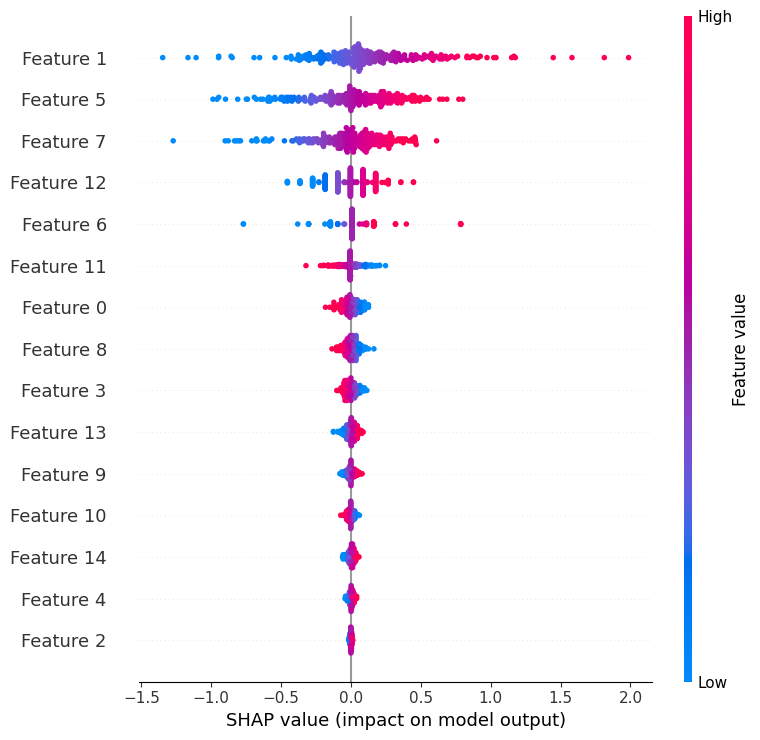

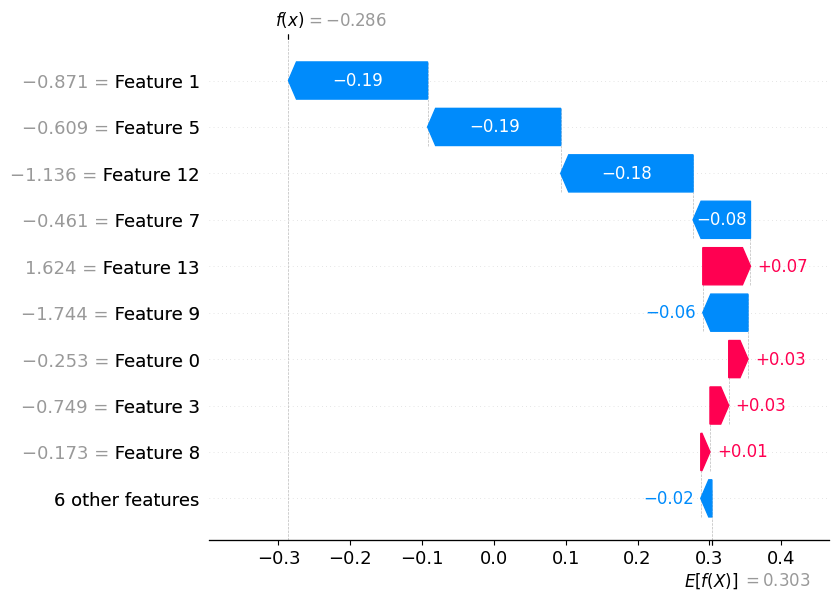

In [66]:
X = numerical_feature.drop(columns="draft_wr_diff")
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])


**With Draft Winrate**

Feature Coefficient:
 [[-0.0826935   0.57048153 -0.05295166 -0.00768826 -0.13093663  0.09590103
   0.38177789  0.25893672  0.23865383 -0.10110839 -0.01500818  0.00349923
  -0.07622415  0.12220893  0.13499625 -0.06049603]]
Accuracy Score: 0.6614785992217899.
Loss Score: 0.609999163706183.
ROC-AUC Score: 0.7289134662129315.
Matrix Confusion: [[74 47]
 [40 96]].


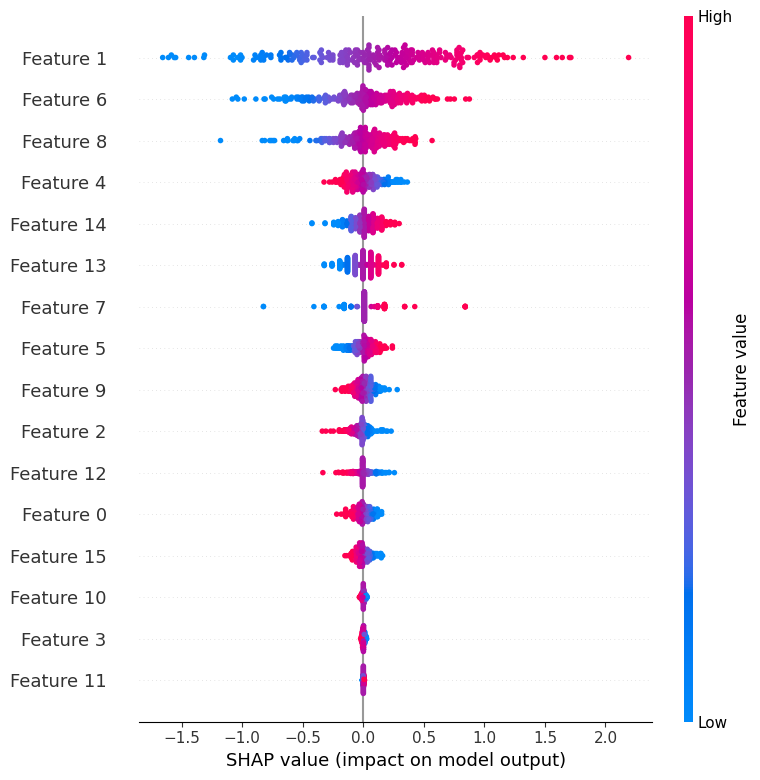

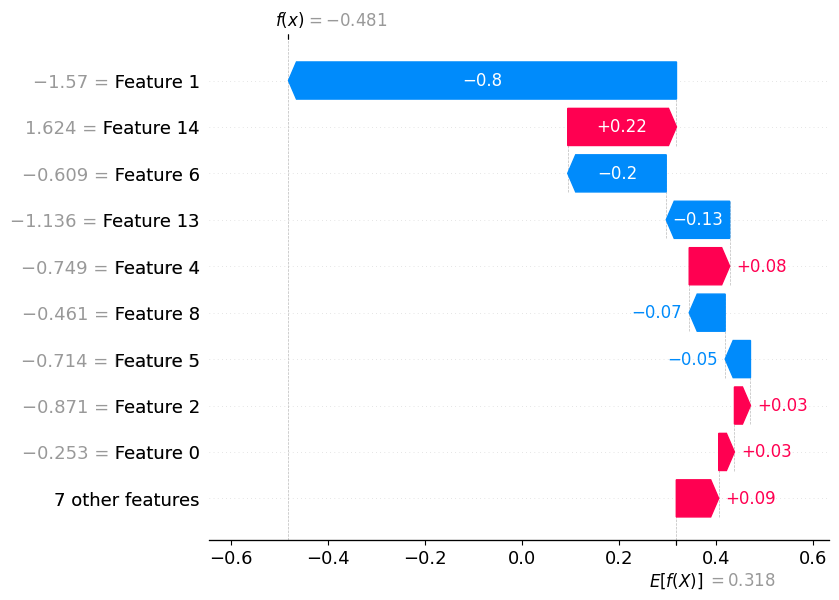

In [67]:
X = numerical_feature
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Insight**
- Draft Intelligence improve a slight model performance and deals a huge influnce for model to make decision.

### Experiment 2 - With and Without Elo Difference

**Without Elo Difference**

Feature Coefficient:
 [[-0.08120484  0.52798997 -0.00898158 -0.13129583  0.09198853  0.38247832
   0.2572025   0.2405885  -0.09823336 -0.00981374  0.00261191 -0.07790284
   0.12067118  0.12798388 -0.05538347]]
Accuracy Score: 0.669260700389105.
Loss Score: 0.6074292487159897.
ROC-AUC Score: 0.7334103062712688.
Matrix Confusion: [[75 46]
 [39 97]].


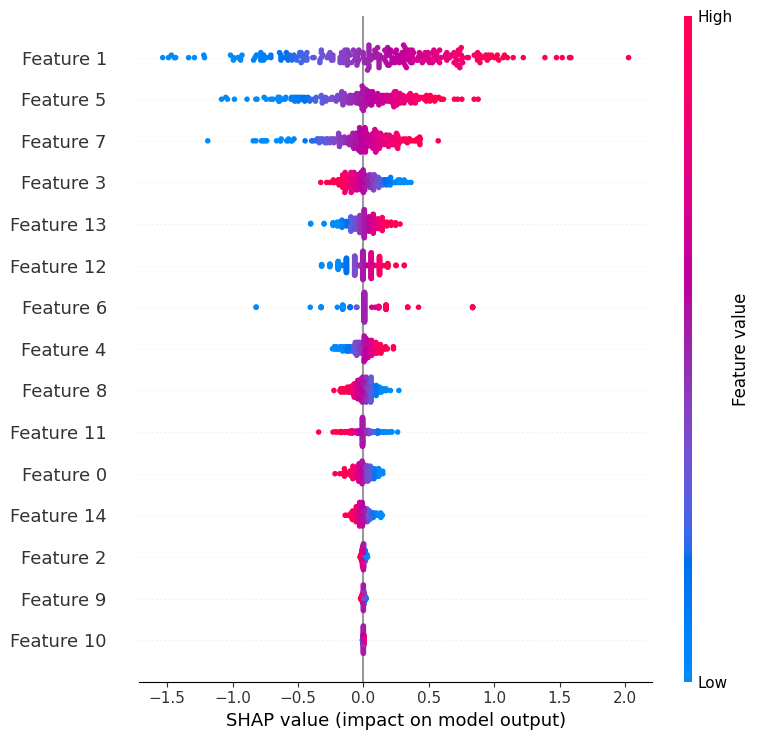

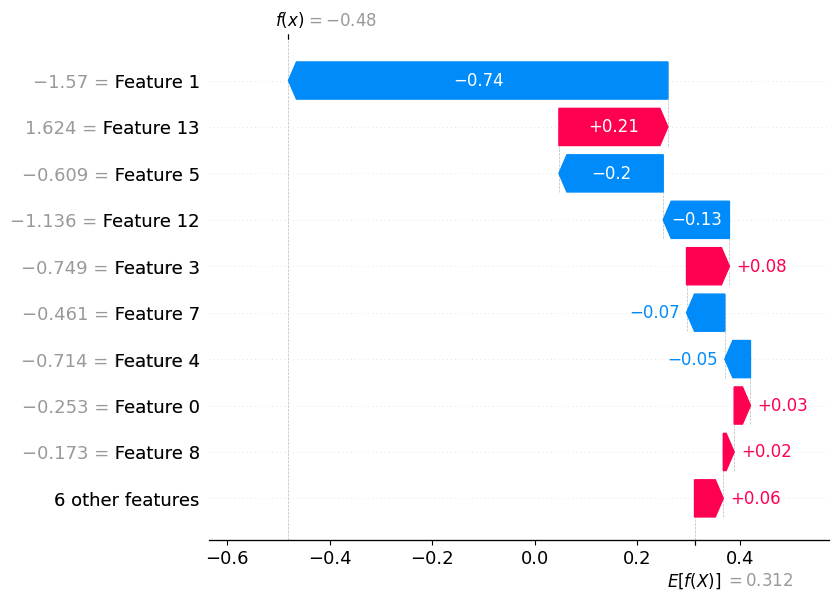

In [68]:
X = numerical_feature.drop(columns="elo_diff")
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**With Elo Difference**

Feature Coefficient:
 [[-0.0826935   0.57048153 -0.05295166 -0.00768826 -0.13093663  0.09590103
   0.38177789  0.25893672  0.23865383 -0.10110839 -0.01500818  0.00349923
  -0.07622415  0.12220893  0.13499625 -0.06049603]]
Accuracy Score: 0.6614785992217899.
Loss Score: 0.609999163706183.
ROC-AUC Score: 0.7289134662129315.
Matrix Confusion: [[74 47]
 [40 96]].


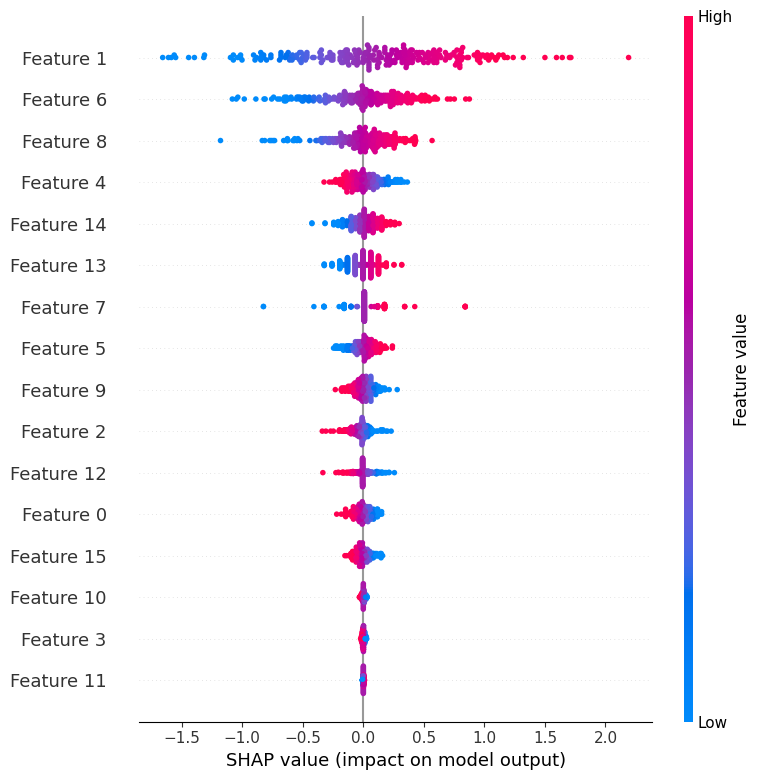

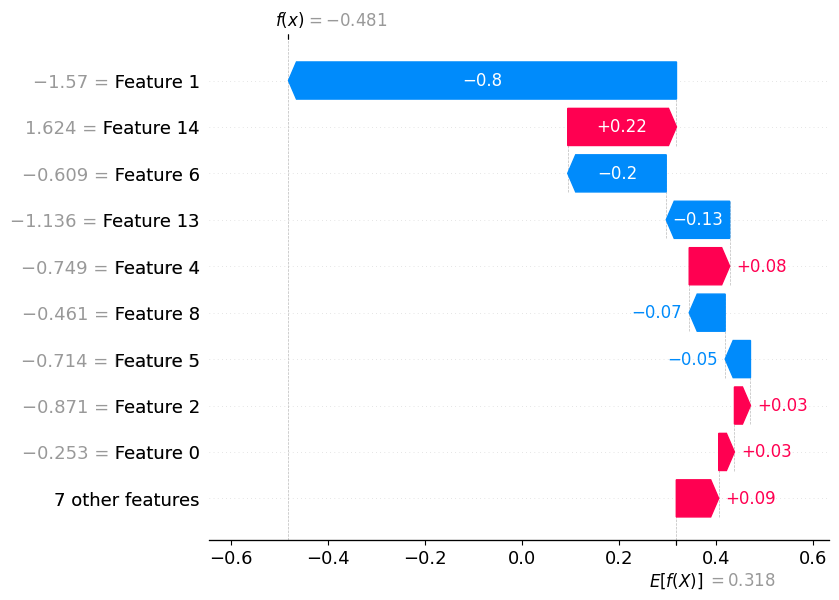

In [69]:
X = numerical_feature
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

**Insight**
- Elo difference decrease a slight model performance but still an important feature represent team strenght

### Feature with coef greater than 0.1 or less than -0.1

Feature Coefficient:
 [[ 0.5522532  -0.05224801  0.35258193  0.26170478  0.204369   -0.10954239
   0.07950766  0.13266404]]
Accuracy Score: 0.6770428015564203.
Loss Score: 0.6083103539854027.
ROC-AUC Score: 0.7290350024307244.
Matrix Confusion: [[76 45]
 [38 98]].


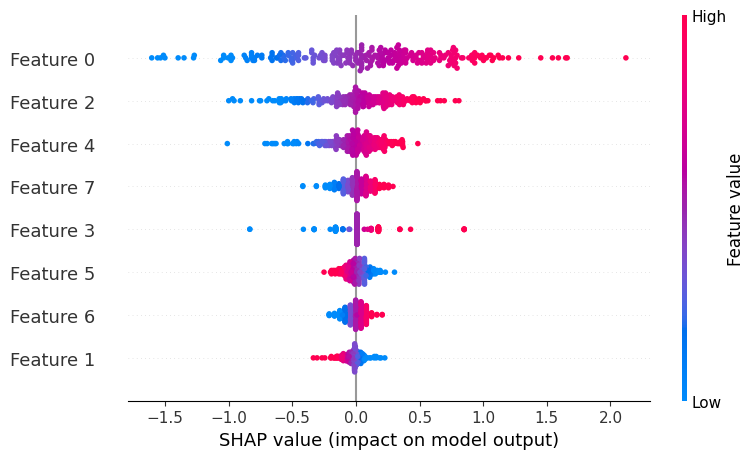

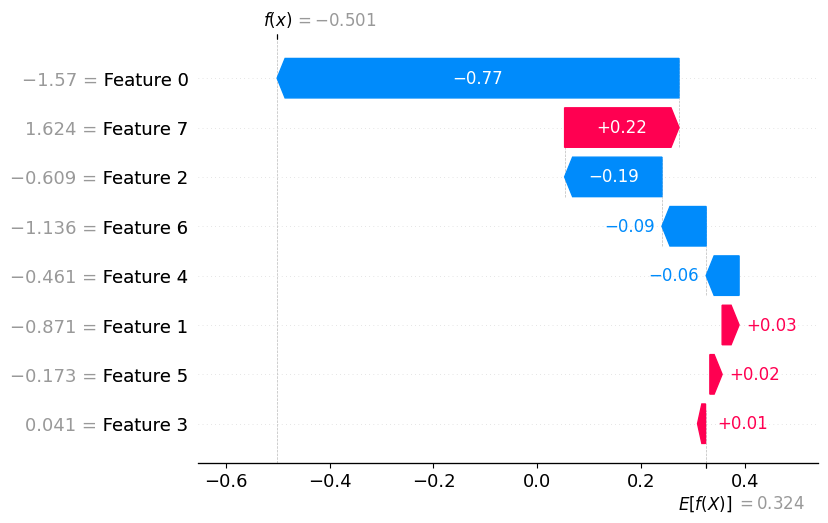

In [70]:
X = numerical_feature[["draft_wr_diff", "elo_diff", "early_gold_diff", "is_mid_rate_diff", "mid_gold_diff", "is_late_rate_diff", "winrate_diff", "momentum_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_proba > 0.6).astype(int)

print("Feature Coefficient:\n", model.coef_)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_pred_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}.")
print(f"Matrix Confusion: {confusion_matrix(y_test, y_pred)}.")

explainer = shap.LinearExplainer(model, X_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)
shap.plots.waterfall(shap_values[0])

Logistic
[[ 0.55297083 -0.05272608  0.35265414  0.26268175  0.2044593  -0.10957668
   0.07932893  0.13273025]]


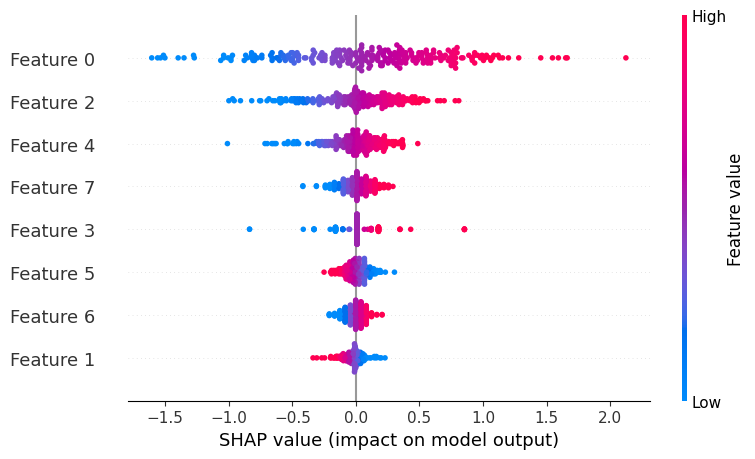

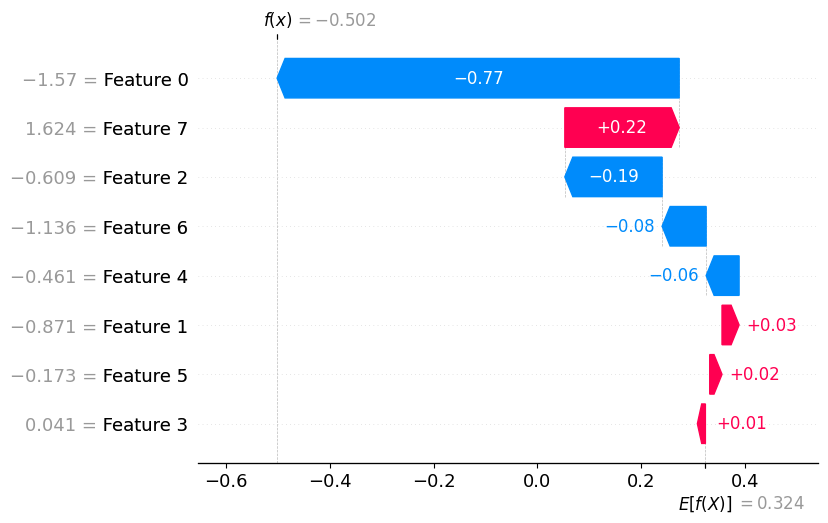

RF
             feature  importance
2    early_gold_diff    0.176677
4      mid_gold_diff    0.166685
1           elo_diff    0.154915
0      draft_wr_diff    0.153519
5  is_late_rate_diff    0.116405
6       winrate_diff    0.085074
7      momentum_diff    0.077411
3   is_mid_rate_diff    0.069315
RF
not list
(257, 8, 2)


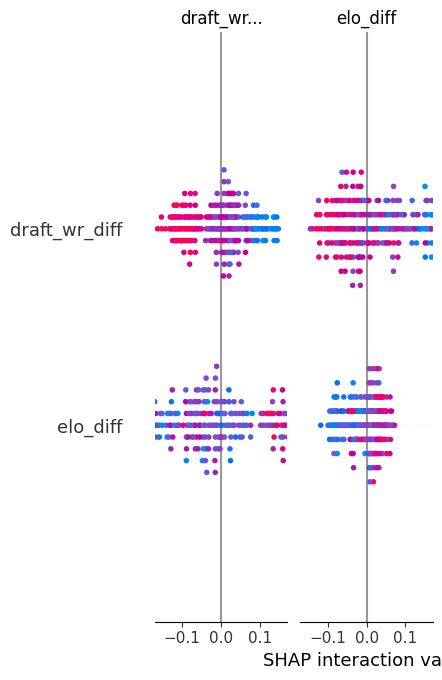

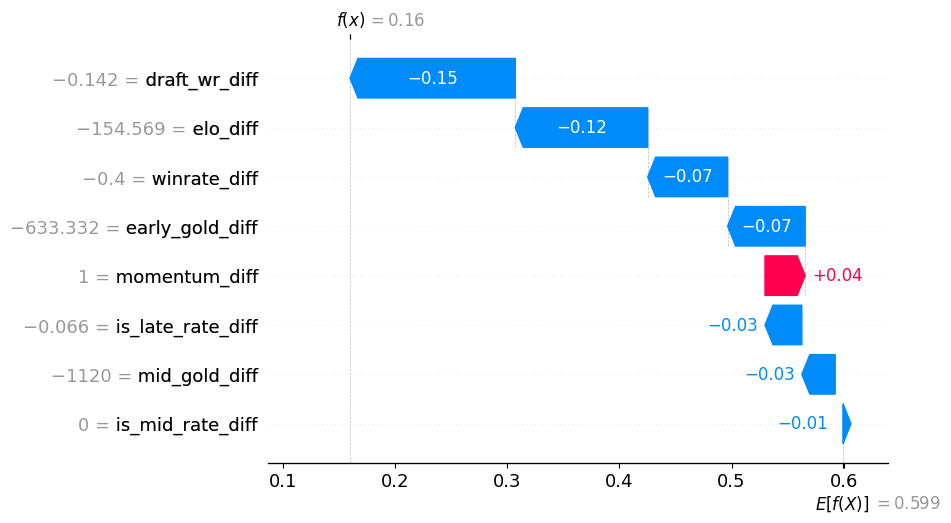

XGB
             feature  importance
3   is_mid_rate_diff    0.161892
2    early_gold_diff    0.155742
0      draft_wr_diff    0.128805
6       winrate_diff    0.118120
1           elo_diff    0.114117
7      momentum_diff    0.113171
4      mid_gold_diff    0.108768
5  is_late_rate_diff    0.099384
XGB
not list
(257, 8)


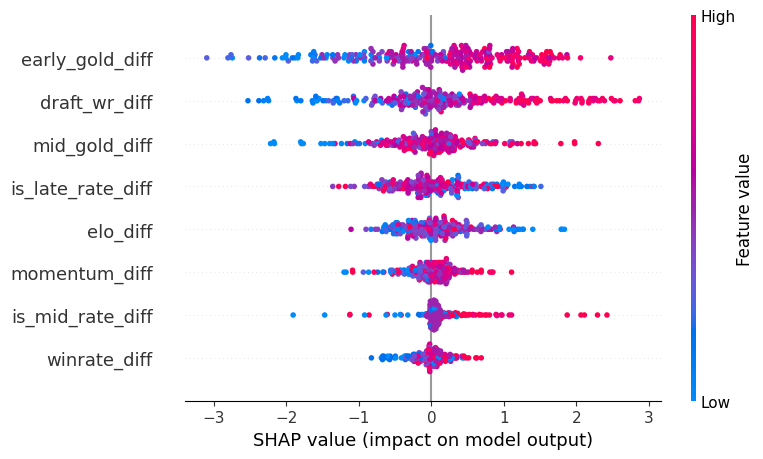

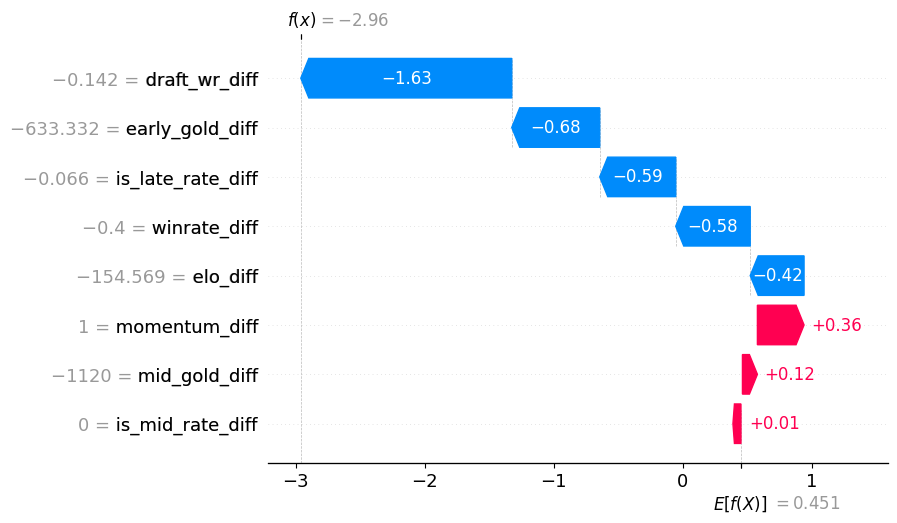

,model,Loss,Acc,ROC_AUC,F1,CM
0,LogisticRegression(),0.608347,0.614786,0.729035,0.543779,"[[99, 22], [77, 59]]"
1,"(DecisionTreeClassifier(max_features='sqrt', r...",0.614168,0.595331,0.711260,0.480000,"[[105, 16], [88, 48]]"
2,"XGBClassifier(base_score=None, booster=None, c...",0.902425,0.564202,0.657207,0.559055,"[[74, 47], [65, 71]]"


In [ ]:
X = numerical_feature[["draft_wr_diff", "elo_diff", "early_gold_diff", "is_mid_rate_diff", "mid_gold_diff", "is_late_rate_diff", "winrate_diff", "momentum_diff"]]
y = df_final["label"].astype(int)

# # Count Label Distribution
# print(y.value_counts(normalize=True))

result = []

model = {
    "Logistic": LogisticRegression(),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier()
}

for name, model, in model.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    if name == "Logistic":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)

    if name == "RF" or name == "XGB":
        # Feature Importance
        importance = model.feature_importances_

        feat_imp = pd.DataFrame({
            "feature": X.columns,
            "importance": importance
        }).sort_values(by="importance", ascending=False)
        print(name)
        print(feat_imp)
    
    if name == "Logistic":
        print(name)
        print(model.coef_)
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer(X_test)
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])

    if name == "RF":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0, :, 1])
    
    if name == "XGB":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])
    
    y_pred_probability = model.predict_proba(X_test)[:,1]
    y_pred = (y_pred_probability > 0.75).astype(int)    

    result.append({
        "model": model,
        "Loss": log_loss(y_test, y_pred_probability),
        "Acc": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred_probability),
        "F1": f1_score(y_test, y_pred),
        "CM": confusion_matrix(y_test, y_pred)})

pd.DataFrame(result)

In [ ]:
X = numerical_feature[["draft_wr_diff", "elo_diff", "early_gold_diff", "is_mid_rate_diff", "mid_gold_diff", "is_late_rate_diff", "winrate_diff", "momentum_diff"]]
y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.5).astype(int)

threshold = np.linspace(0.3, 0.7, 50)

best_f1 = 0
best_threshold = 0.5

for t in threshold:
    y_pred = (y_proba > t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        print(f"Current f1 Score: {f1}")
        best_f1 = f1
        best_t = t

print(f"Best threshold: {best_f1}.")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba)}.")
print(f"Confusion matrix : {confusion_matrix(y_test, y_pred)}.")

Best threshold: 0.7582089552238805.
Accuracy Score: 0.6381322957198443.
Loss Score: 0.5978245621376634.
ROC-AUC Score: 0.7407632474477394.
Confusion matrix : [[95 26]
 [67 69]].


c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
coef = model.coef_[0]
for f, c in zip(X.columns, coef):
    print(f"{f}: {c}")

draft_wr_diff: 2.1352057793609935
elo_diff: 0.0008910767963603276
early_gold_diff: 0.0002898081224307265
is_mid_rate_diff: 1.3510870938624795
mid_gold_diff: 8.524546180790622e-05
is_late_rate_diff: -0.289824233991831
winrate_diff: 0.3182037709132522
momentum_diff: 0.11100711171617575


In [39]:
sample = [[0.2, 50, -1600, 0.5, 300, 0.9, -0.3, 0.1]]

proba = model.predict_proba(sample)[0][1]
print(f"probalilitas home menang: {proba}")

probalilitas home menang: 0.6776467073460214


c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [44]:
df_eval = X_test.copy()
df_eval["y_true"] = y_test
df_eval["y_pred"] = y_pred
df_eval["proba"] = y_proba
fn = df_eval[(df_eval["y_true"] == 0) & (df_eval["y_pred"] == 0)]
fn.sort_values(by="proba", ascending=True)

,draft_wr_diff,elo_diff,early_gold_diff,is_mid_rate_diff,mid_gold_diff,is_late_rate_diff,winrate_diff,momentum_diff,y_true,y_pred,proba
1196,-0.176000,-233.779676,-2590.000000,-0.2000,-9650.000000,-0.200,-1.000000,0.000000,0,0,0.090411
1156,-0.146000,-228.324462,-1740.000000,0.0000,-14866.666000,0.034,-0.800000,-0.500000,0,0,0.097305
1181,-0.150000,-87.830300,-3420.000000,-0.2000,-9466.666000,-0.334,-0.800000,0.333333,0,0,0.098990
1209,-0.182000,-168.852377,-3106.666000,-0.2000,-7286.666000,-0.434,-1.000000,0.000000,0,0,0.104890
1183,-0.188000,-184.280576,-2390.000000,0.0000,-10580.000000,-0.234,-1.000000,0.000000,0,0,0.115946
...,...,...,...,...,...,...,...,...,...,...,...
1217,0.084000,8.281946,-80.000000,0.0000,1126.666000,-0.266,0.000000,0.000000,0,0,0.671692
1130,0.028000,66.083901,412.500000,-0.0375,1135.832500,0.201,0.050000,1.000000,0,0,0.675288
1187,0.088000,-110.056608,196.668000,-0.0660,466.666000,-0.298,0.200000,1.166667,0,0,0.680509
1034,0.170000,163.308340,-440.000000,0.0000,-215.000000,-0.068,0.000000,0.000000,0,0,0.681686


## Insights

**Error Analysis**

- Model struggle on close match like small draft winrate difference and elo difference, resulting in prediction uncertainty.
- Model is overconfident on early and mid game gold difference then misclassification when comeback scenario.

**Segment Analysis**

- Model is accurately predict the match with draft strength and power strength gap are huge rather than a tight gap strength match.
- Draft and mid game economy are overshadowing features elo and early game economy.